# 02. Exploratory analysis

Charts and numbers behind BQ1 to BQ3. Everything reads from `data/processed`. Revenue always means price + freight on delivered orders, the same definition as the SQL layer. Each figure is saved to `reports/figures/` and has to make sense without this notebook next to it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns

P = Path("../data/processed")
FIG = Path("../reports/figures")

orders = pd.read_parquet(P / "orders.parquet")
items = pd.read_parquet(P / "order_items.parquet")
customers = pd.read_parquet(P / "customers.parquet")
reviews = pd.read_parquet(P / "reviews.parquet")
payments = pd.read_parquet(P / "payments.parquet")
products = pd.read_parquet(P / "products.parquet")

sns.set_theme(style="whitegrid")
BLUE, RED, GREY = "#4C72B0", "#C44E52", "#999999"

delivered = orders[
    (orders["order_status"] == "delivered") & orders["order_delivered_customer_date"].notna()
].copy()
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.days
# compare dates, not timestamps: an order due May 5 that arrives May 5 at 22:00 is on time
delivered["delay_days"] = (
    delivered["order_delivered_customer_date"].dt.normalize()
    - delivered["order_estimated_delivery_date"].dt.normalize()
).dt.days

print(f"{len(delivered):,} delivered orders with a delivery date, "
      f"{(delivered['delay_days'] > 0).mean():.1%} of them late, "
      f"median {delivered['delivery_days'].median():.0f} days to deliver")

96,470 delivered orders with a delivery date, 6.8% of them late, median 10 days to deliver


## Delivery delay vs review score

The question with the most money on it. Compare the delivery date against the promise shown at checkout, bucket the gap, average the review score per bucket.

                mean_score  low_share      n
delay_bucket                                
Early                 4.29       0.09  88163
On the day            4.03       0.12   1280
1-7 days late         2.71       0.49   3600
8-14 days late        1.67       0.80   1446
15+ days late         1.72       0.78   1335


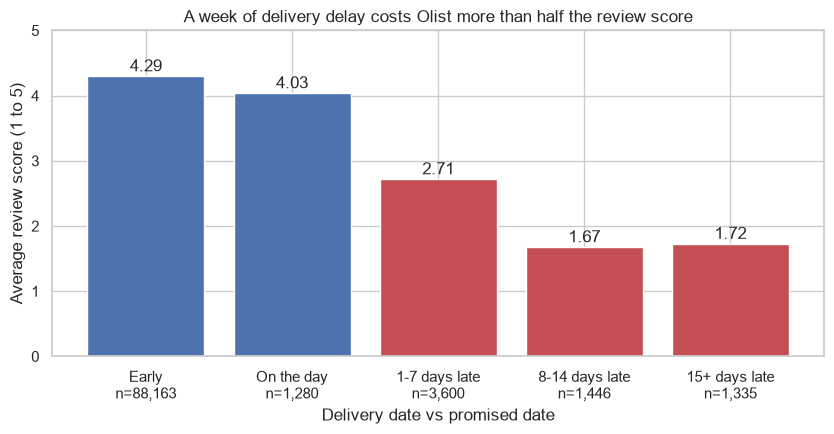

In [2]:
delay_labels = ["Early", "On the day", "1-7 days late", "8-14 days late", "15+ days late"]
dr = delivered.merge(reviews[["order_id", "review_score"]], on="order_id")
dr["delay_bucket"] = pd.cut(dr["delay_days"], [-1000, -1, 0, 7, 14, 1000], labels=delay_labels)

score_by_delay = dr.groupby("delay_bucket", observed=True)["review_score"].agg(
    mean_score="mean", low_share=lambda s: (s <= 2).mean(), n="size"
)
print(score_by_delay.round(2).to_string())

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.bar(range(5), score_by_delay["mean_score"], color=[BLUE, BLUE, RED, RED, RED])
for i, mean_score in enumerate(score_by_delay["mean_score"]):
    ax.text(i, mean_score + 0.08, f"{mean_score:.2f}", ha="center")
ax.set_xticks(range(5), [f"{label}\nn={n:,}" for label, n in zip(delay_labels, score_by_delay["n"])])
ax.set_ylim(0, 5)
ax.set_ylabel("Average review score (1 to 5)")
ax.set_xlabel("Delivery date vs promised date")
ax.set_title("A week of delivery delay costs Olist more than half the review score")
fig.tight_layout()
fig.savefig(FIG / "01_review_score_by_delivery_delay.png", dpi=150, bbox_inches="tight")
plt.show()

Any lateness roughly halves the score: 4.29 stars when early, 2.71 at 1 to 7 days late, 1.67 at 8 to 14. Past a week late, 80% of reviews land at 1 or 2 stars. Lateness is rare, 6.8% of orders, but when it happens the review is nearly always lost. This is the core of BQ3 and the reason BQ4 is worth modeling.

## Order value distribution

What a typical basket looks like, and how heavy the tail is.

median R$105.28, mean R$159.83, p95 R$446.26, p99 R$1052.40, max R$13,664.08


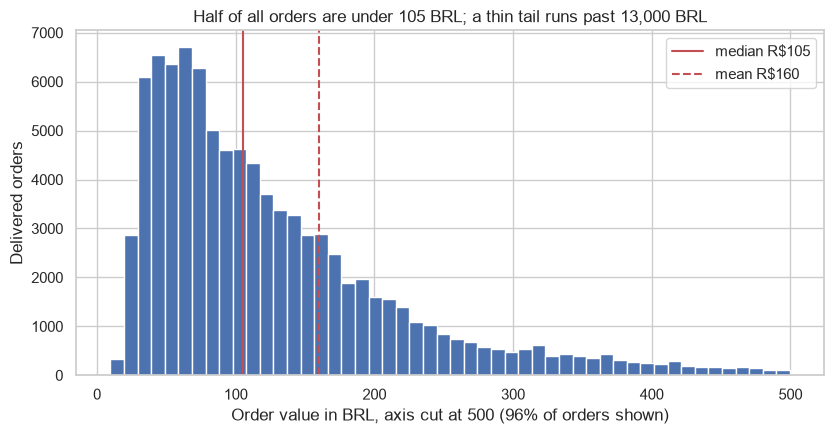

In [3]:
order_value = (items["price"] + items["freight_value"]).groupby(items["order_id"]).sum()
ov = order_value[order_value.index.isin(delivered["order_id"])]
print(f"median R${ov.median():.2f}, mean R${ov.mean():.2f}, "
      f"p95 R${ov.quantile(0.95):.2f}, p99 R${ov.quantile(0.99):.2f}, max R${ov.max():,.2f}")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.hist(ov[ov <= 500], bins=50, color=BLUE)
ax.axvline(ov.median(), color=RED, lw=1.5, label=f"median R${ov.median():.0f}")
ax.axvline(ov.mean(), color=RED, lw=1.5, ls="--", label=f"mean R${ov.mean():.0f}")
ax.set_xlabel(f"Order value in BRL, axis cut at 500 ({(ov <= 500).mean():.0%} of orders shown)")
ax.set_ylabel("Delivered orders")
ax.set_title("Half of all orders are under 105 BRL; a thin tail runs past 13,000 BRL")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "02_order_value_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Median order is R$105.28 against a mean of R$159.83, the usual right skew: 1% of orders top R$1,052 and the largest is R$13,664. Average order value alone would overstate the typical basket by half.

## Monthly revenue trend

Revenue by purchase month. Two windows need care: late 2016 is nearly empty, and orders placed after Aug 2018 were mostly still in transit when the snapshot was taken, so the delivered series stops there.

peak Nov 2017: R$1,153,229 | total R$15,418,395


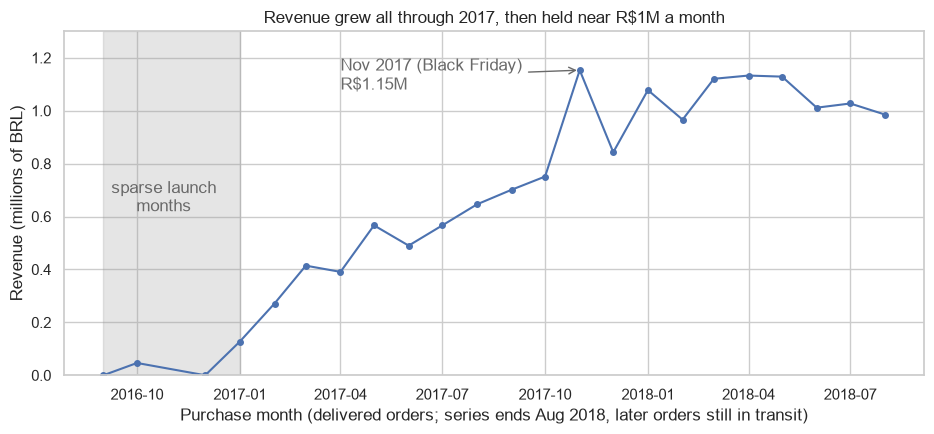

In [4]:
delivered_items = items.merge(delivered[["order_id", "order_purchase_timestamp"]], on="order_id")
delivered_items["revenue"] = delivered_items["price"] + delivered_items["freight_value"]
monthly = delivered_items.groupby(
    delivered_items["order_purchase_timestamp"].dt.to_period("M")
)["revenue"].sum()
monthly.index = monthly.index.to_timestamp()
peak = monthly.idxmax()
print(f"peak {peak:%b %Y}: R${monthly.max():,.0f} | total R${monthly.sum():,.0f}")

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(monthly.index, monthly / 1e6, marker="o", ms=4, color=BLUE)
ax.axvspan(pd.Timestamp("2016-09-01"), pd.Timestamp("2017-01-01"), color=GREY, alpha=0.25)
ax.text(pd.Timestamp("2016-10-25"), 0.62, "sparse launch\nmonths", ha="center", color="dimgray")
ax.annotate(f"Nov 2017 (Black Friday)\nR${monthly.max()/1e6:.2f}M",
            xy=(peak, monthly.max() / 1e6), xytext=(pd.Timestamp("2017-04-01"), 1.08),
            arrowprops=dict(arrowstyle="->", color="dimgray"), color="dimgray")
ax.set_ylabel("Revenue (millions of BRL)")
ax.set_xlabel("Purchase month (delivered orders; series ends Aug 2018, later orders still in transit)")
ax.set_title("Revenue grew all through 2017, then held near R$1M a month")
ax.set_ylim(0, 1.3)
fig.tight_layout()
fig.savefig(FIG / "03_monthly_revenue_trend.png", dpi=150, bbox_inches="tight")
plt.show()

From R$46k in Oct 2016 to a R$1.15M peak in Nov 2017, then a plateau just under R$1M a month through 2018. Total delivered revenue: R$15.4M. Growth stalled in 2018; the money story after that point is about mix and retention, not volume.

## Revenue by state

Where the money comes from geographically.

SP 37.4%, top 3 62.5% of revenue


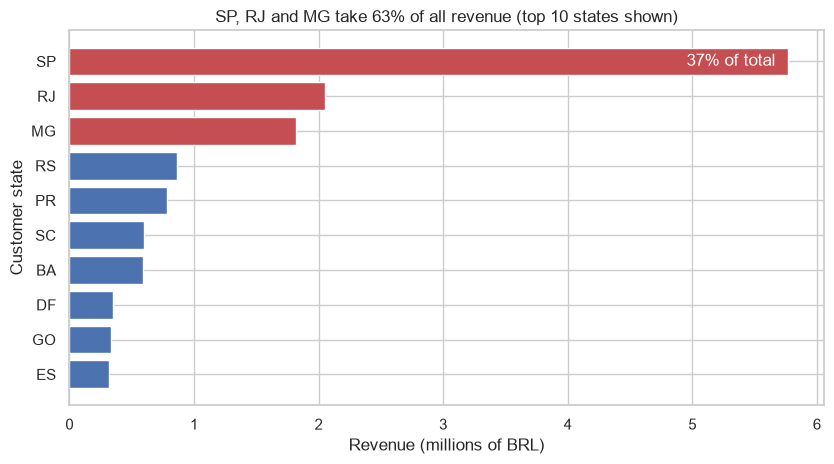

In [5]:
state_revenue = (
    items.merge(delivered[["order_id", "customer_id"]], on="order_id")
    .merge(customers[["customer_id", "customer_state"]], on="customer_id")
    .assign(revenue=lambda df: df["price"] + df["freight_value"])
    .groupby("customer_state")["revenue"].sum()
    .sort_values(ascending=False)
)
top3_share = state_revenue.head(3).sum() / state_revenue.sum()
print(f"SP {state_revenue.iloc[0]/state_revenue.sum():.1%}, top 3 {top3_share:.1%} of revenue")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
top10 = state_revenue.head(10)
ax.barh(top10.index, top10 / 1e6, color=[RED] * 3 + [BLUE] * 7)
ax.invert_yaxis()
ax.text(top10.iloc[0] / 1e6 - 0.1, 0, f"{top10.iloc[0]/state_revenue.sum():.0%} of total",
        va="center", ha="right", color="white")
ax.set_xlabel("Revenue (millions of BRL)")
ax.set_ylabel("Customer state")
ax.set_title("SP, RJ and MG take 63% of all revenue (top 10 states shown)")
fig.tight_layout()
fig.savefig(FIG / "04_revenue_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

Sao Paulo alone is 37.4% of revenue and the three southeastern states together take 62.5%. The delivery-performance flip side: the North and Northeast pay more freight and wait longer, which shows up again in the state delivery table from the SQL layer.

## Category revenue concentration

74 categories exist. How many actually matter?

18 of 74 categories reach 80% of revenue; top 5 take 39.3%


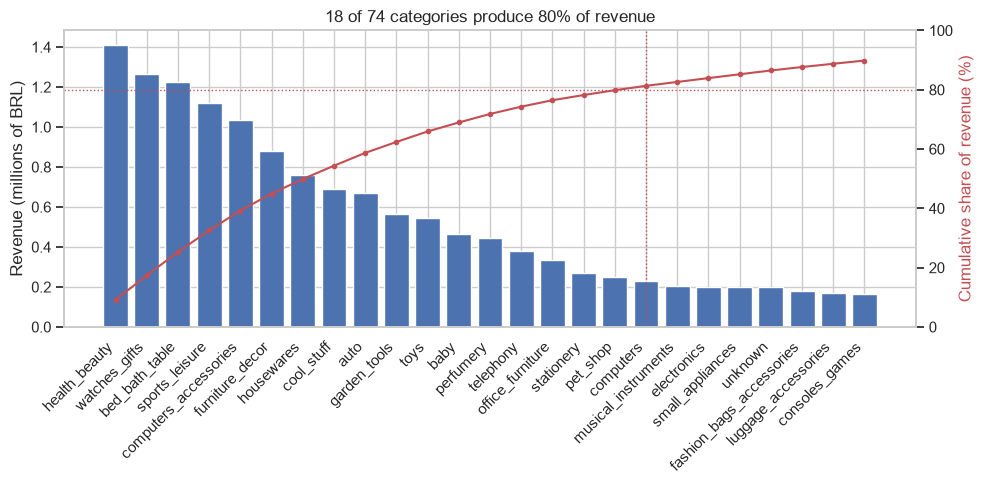

In [6]:
category_revenue = (
    items.merge(delivered[["order_id"]], on="order_id")
    .merge(products[["product_id", "product_category_name_english"]], on="product_id")
    .assign(category=lambda df: df["product_category_name_english"].fillna("unknown"),
            revenue=lambda df: df["price"] + df["freight_value"])
    .groupby("category")["revenue"].sum()
    .sort_values(ascending=False)
)
cumulative_share = category_revenue.cumsum() / category_revenue.sum()
n_for_80 = (cumulative_share < 0.80).sum() + 1
print(f"{n_for_80} of {len(category_revenue)} categories reach 80% of revenue; "
      f"top 5 take {category_revenue.head(5).sum()/category_revenue.sum():.1%}")

fig, ax = plt.subplots(figsize=(10, 5))
shown = 25
ax.bar(range(shown), category_revenue.head(shown) / 1e6, color=BLUE)
ax.set_xticks(range(shown), category_revenue.head(shown).index, rotation=45, ha="right")
ax.set_ylabel("Revenue (millions of BRL)")
ax.set_title(f"{n_for_80} of {len(category_revenue)} categories produce 80% of revenue")
ax2 = ax.twinx()
ax2.plot(range(shown), cumulative_share.head(shown) * 100, color=RED, marker=".")
ax2.axhline(80, color=RED, ls=":", lw=1)
ax2.axvline(n_for_80 - 1, color=RED, ls=":", lw=1)
ax2.set_ylabel("Cumulative share of revenue (%)", color=RED)
ax2.set_ylim(0, 100)
ax2.grid(False)
fig.tight_layout()
fig.savefig(FIG / "05_category_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

18 of 74 categories cover 80% of revenue, and the top 5 (health_beauty, watches_gifts, bed_bath_table, sports_leisure, computers_accessories) already hold 39.3%. Category investment decisions live in a short list, not in 74 lines.

## Payment methods and installments

How customers pay, and how much they stretch card payments.

credit card 78.5% of value | 33.2% of card payments in 1 installment, 7.3% in 10+


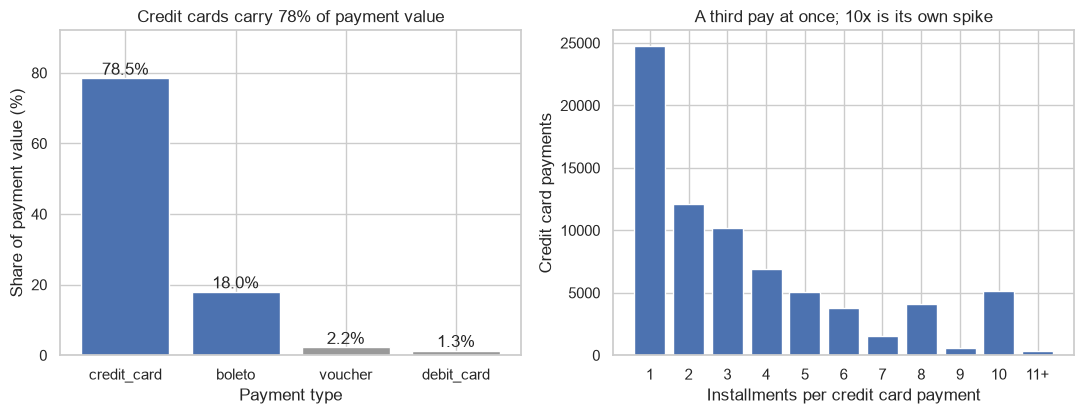

In [7]:
delivered_payments = payments[payments["order_id"].isin(delivered["order_id"])]
value_share = (
    delivered_payments.groupby("payment_type")["payment_value"].sum().sort_values(ascending=False)
)
value_share = value_share / value_share.sum()

card = delivered_payments[delivered_payments["payment_type"] == "credit_card"]
installments = card["payment_installments"].clip(upper=11).value_counts().sort_index()
print(f"credit card {value_share.iloc[0]:.1%} of value | "
      f"{(card['payment_installments'] == 1).mean():.1%} of card payments in 1 installment, "
      f"{(card['payment_installments'] >= 10).mean():.1%} in 10+")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].bar(value_share.index, value_share * 100, color=[BLUE, BLUE, GREY, GREY])
for i, share in enumerate(value_share):
    axes[0].text(i, share * 100 + 1, f"{share:.1%}", ha="center")
axes[0].set_ylabel("Share of payment value (%)")
axes[0].set_xlabel("Payment type")
axes[0].set_title("Credit cards carry 78% of payment value")
axes[0].set_ylim(0, 92)

labels = [str(i) for i in range(1, 11)] + ["11+"]
axes[1].bar(labels, installments, color=BLUE)
axes[1].set_xlabel("Installments per credit card payment")
axes[1].set_ylabel("Credit card payments")
axes[1].set_title("A third pay at once; 10x is its own spike")
fig.tight_layout()
fig.savefig(FIG / "06_payment_methods.png", dpi=150, bbox_inches="tight")
plt.show()

Credit cards carry 78.5% of payment value, boleto 18.0%. On cards, 33.2% pay in a single installment and 7.3% stretch to 10 or more. The spike at exactly 10 is a storefront artifact: 10x installment offers are a standard Brazilian retail promotion.

## Repeat purchases

How many customers ever come back, and how fast the second order arrives when they do.

93,350 customers, 2,801 bought again (3.0%) | gap median 28 days, 68% within 90 days


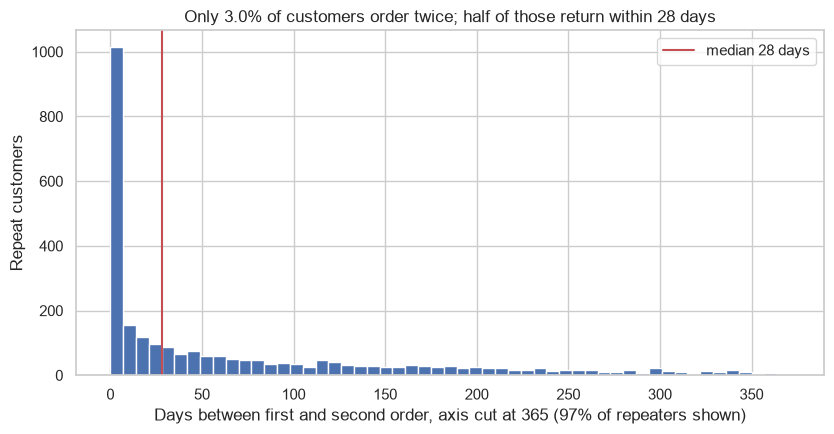

In [8]:
delivered_people = delivered.merge(
    customers[["customer_id", "customer_unique_id"]], on="customer_id"
).sort_values("order_purchase_timestamp")
delivered_people["purchase_rank"] = delivered_people.groupby("customer_unique_id").cumcount()

first = delivered_people[delivered_people["purchase_rank"] == 0].set_index("customer_unique_id")
second = delivered_people[delivered_people["purchase_rank"] == 1].set_index("customer_unique_id")
repeat_rate = len(second) / len(first)
gap_days = (
    second["order_purchase_timestamp"] - first.loc[second.index, "order_purchase_timestamp"]
).dt.days
print(f"{len(first):,} customers, {len(second):,} bought again ({repeat_rate:.1%}) | "
      f"gap median {gap_days.median():.0f} days, {(gap_days <= 90).mean():.0%} within 90 days")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.hist(gap_days[gap_days <= 365], bins=range(0, 372, 7), color=BLUE)
ax.axvline(gap_days.median(), color=RED, lw=1.5, label=f"median {gap_days.median():.0f} days")
ax.set_xlabel(f"Days between first and second order, axis cut at 365 "
              f"({(gap_days <= 365).mean():.0%} of repeaters shown)")
ax.set_ylabel("Repeat customers")
ax.set_title(f"Only {repeat_rate:.1%} of customers order twice; half of those return within "
             f"{gap_days.median():.0f} days")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "07_repeat_purchase_gap.png", dpi=150, bbox_inches="tight")
plt.show()

3.0% of 93,350 customers ever get a second delivered order. The ones who do come back fast: half within 28 days, 68% within 90. If Olist wants a retention play, the window is the first three months; after that the customer is gone.

## Findings

- A week of delivery delay costs more than half the review score: 8 to 14 days late averages 1.67 stars against 4.29 for early orders, and 80% of week-plus-late orders get 1 or 2 stars.
- Lateness is rare but fatal: 6.8% of deliveries miss the promise, yet even early orders only see 9.2% low reviews, so delay is the single sharpest satisfaction lever.
- The typical basket is small: median R$105.28, and 95% of orders stay under R$447.
- Revenue peaked at R$1.15M in Nov 2017 and plateaued near R$1M a month through 2018; two-year total R$15.4M.
- Concentration is double: SP, RJ and MG hold 62.5% of revenue, and 18 of 74 categories hold 80%.
- Credit cards carry 78.5% of payment value; a third of card payments settle in one installment.
- 3.0% of customers ever reorder, and half of the repeaters return within 28 days, so retention efforts have a 90-day window at best.